In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [54]:
enc = OrdinalEncoder(categories=[['no','local','generalized']])
enc.fit([['no'], ['local'], ['generalized']])                                 
df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
df2["Peritonitis"].value_counts(dropna = False)

0.0    189
1.0     43
2.0      6
Name: Peritonitis, dtype: int64

In [55]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.1618742249964222

In [56]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis_binary"] = (df2["Peritonitis"]!=0).astype(int)

In [57]:
#dropping the Peritonitis Columns
df2.drop(["Peritonitis"],axis=1, inplace =True)

In [58]:
df2["Diagnosis"].corr(df2["Peritonitis_binary"])

0.19028246913072036

In [59]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [60]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [61]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [62]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [64]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

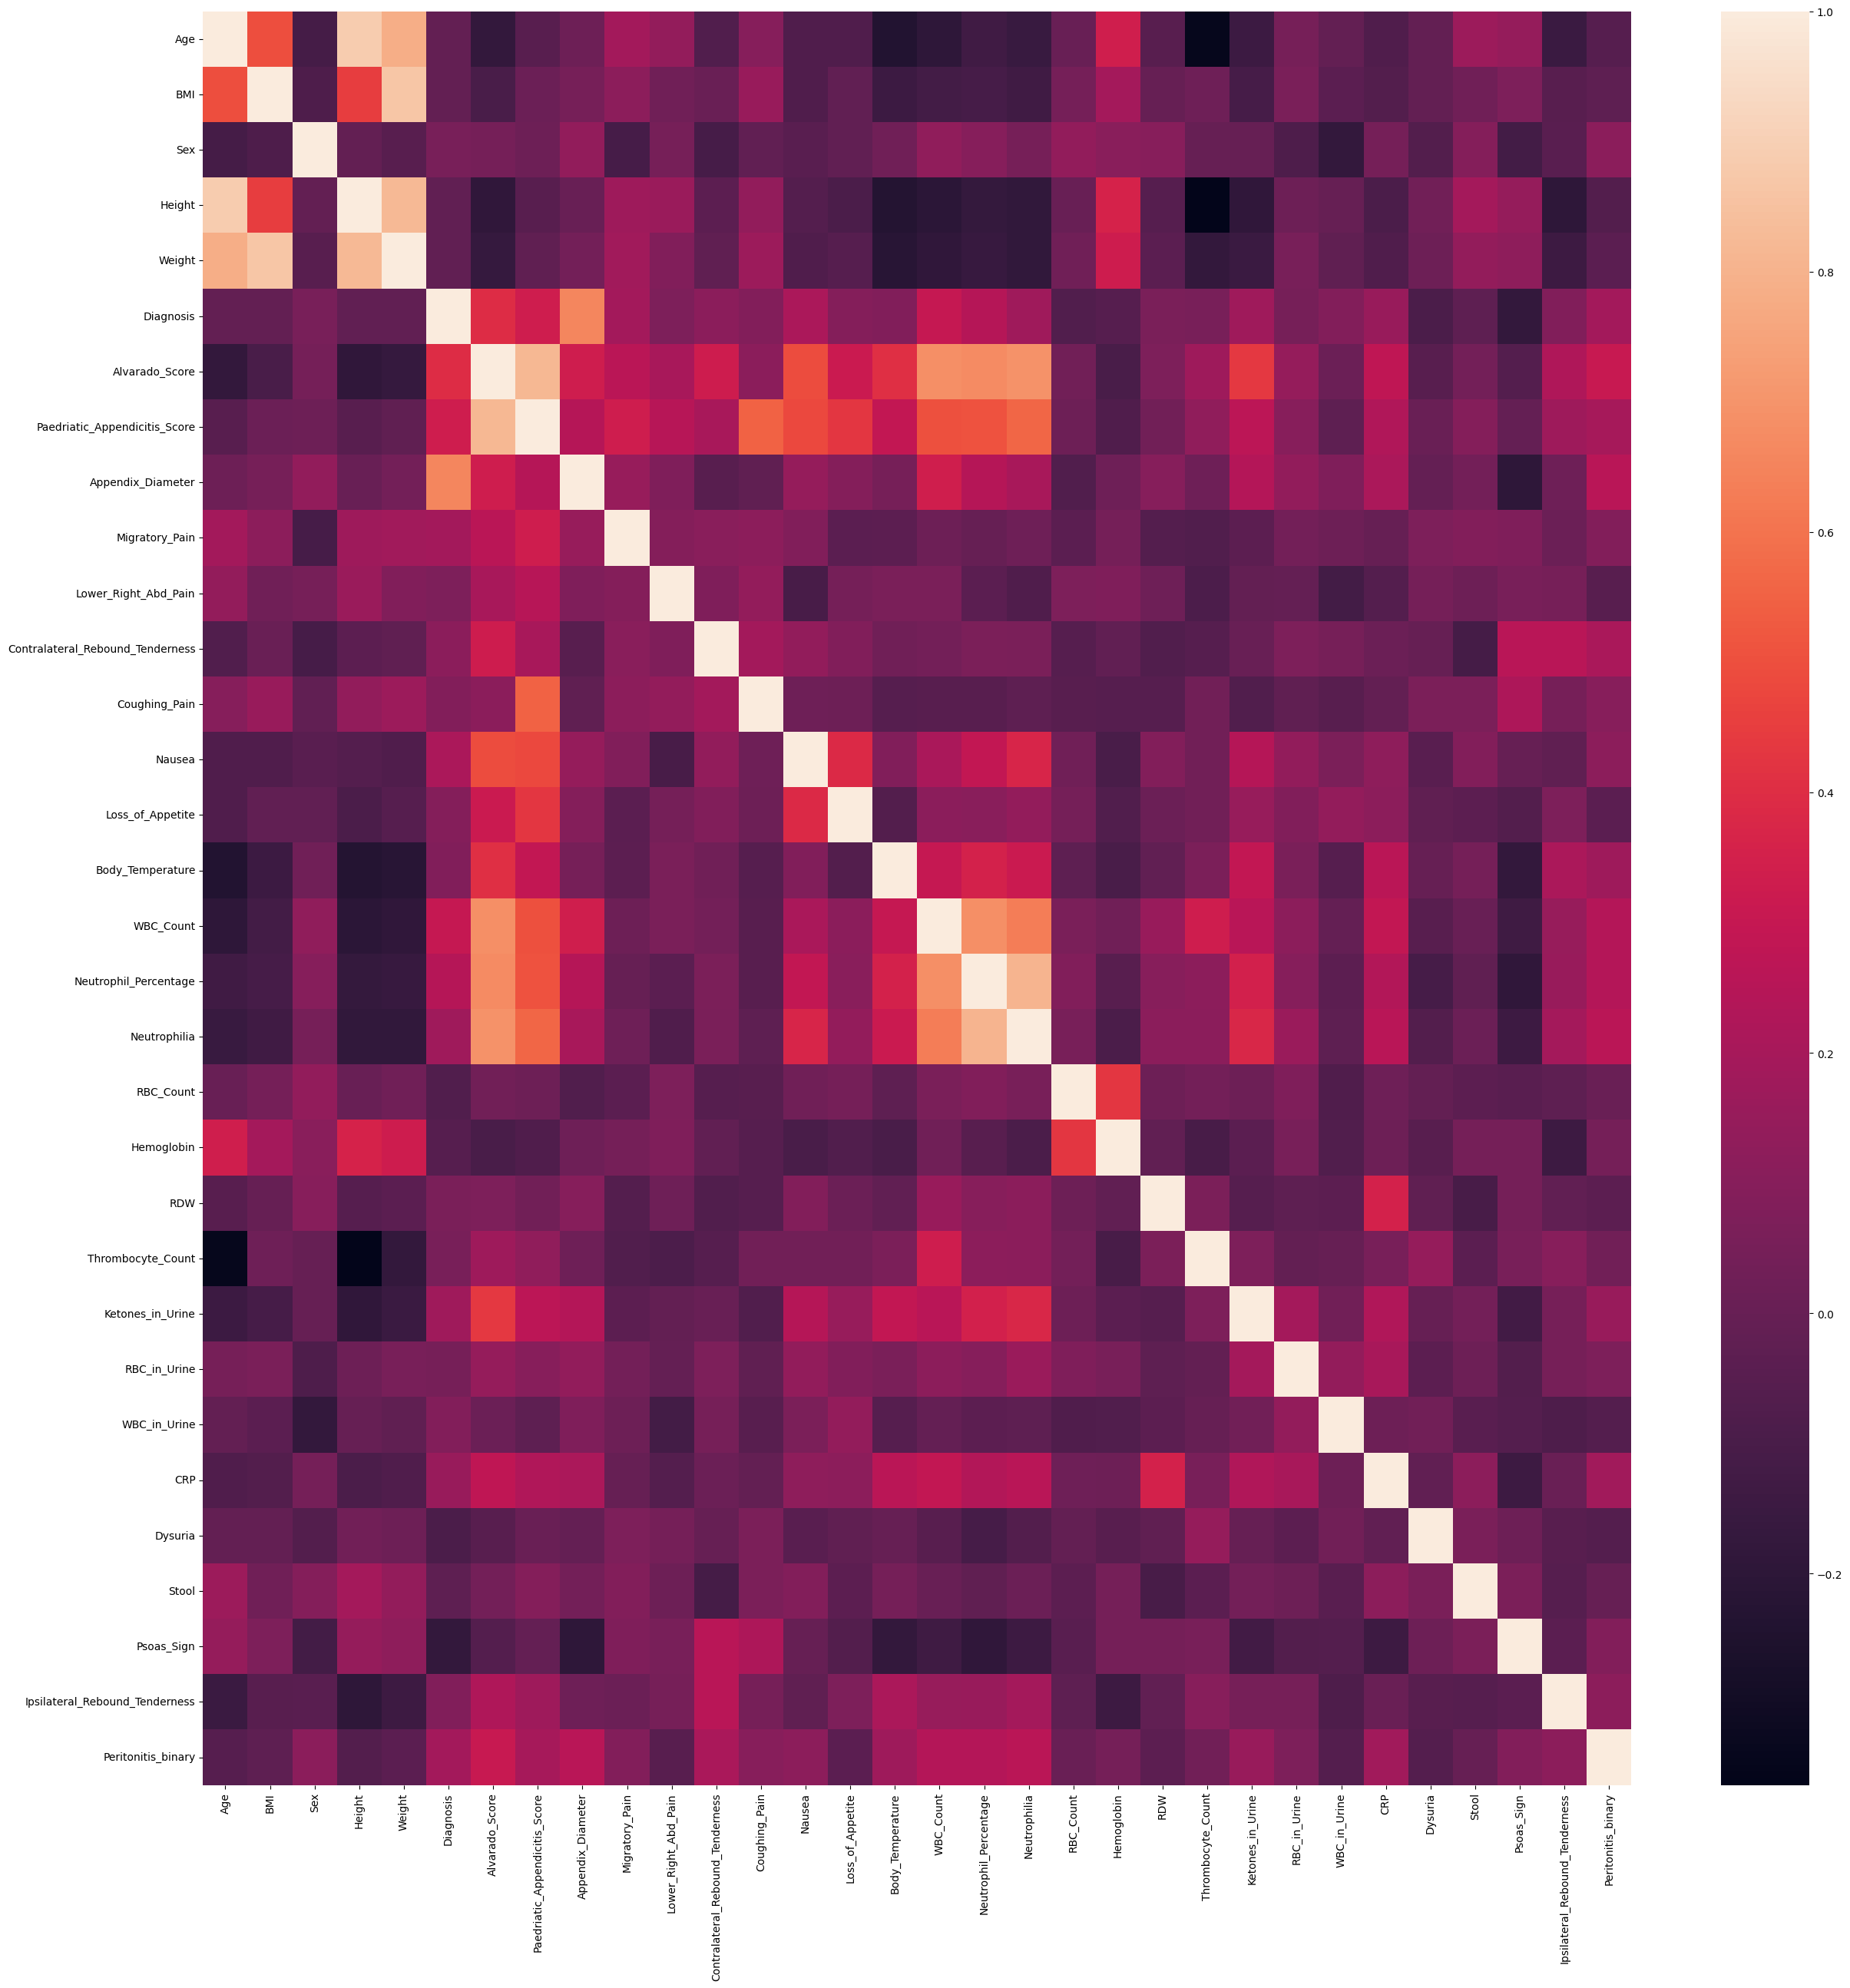

In [65]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [66]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [67]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [68]:
# dsafsf

In [69]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

# APPLYING VARIANCE THRESHOLD FOR FEATURE SELECTION

In [70]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape


mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Stool', 'Psoas_Sign', 'Free_Fluids'],
      dtype='object')

In [71]:
col = selected_cols
col =list(col)
col.append("Diagnosis")
df = df.loc[:,col]

In [72]:
print(list(col))

['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Stool', 'Psoas_Sign', 'Free_Fluids', 'Diagnosis']


In [73]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [74]:
# df4 = df.dropna()
# aaaaaaaaaa

In [75]:
# df4.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 289 entries, 0 to 781
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               289 non-null    float64
 1   BMI                               289 non-null    float64
 2   Sex                               289 non-null    int32  
 3   Height                            289 non-null    float64
 4   Weight                            289 non-null    float64
 5   Alvarado_Score                    289 non-null    float64
 6   Paedriatic_Appendicitis_Score     289 non-null    float64
 7   Appendix_Diameter                 289 non-null    float64
 8   Migratory_Pain                    289 non-null    int32  
 9   Contralateral_Rebound_Tenderness  289 non-null    int32  
 10  Coughing_Pain                     289 non-null    int32  
 11  Nausea                            289 non-null    int32  
 12  Loss_of_

C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\2491435077.py:18: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()
C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\2491435077.py:356: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]
C:\Users\shadj\AppData\Local\Temp\ipykernel_37392\2491435077.py:363: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 289 entries, 0 to 781
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               289 non-null    float64
 1   BMI                               289 non-null    float64
 2   Sex                               289 non-null    int32  
 3   Height                            289 non-null    float64
 4   Weight                            289 non-null    float64
 5   Alvarado_Score                    289 non-null    float64
 6   Paedriatic_Appendicitis_Score     289 non-null    float64
 7   Appendix_Diameter                 289 non-null    float64
 8   Migratory_Pain                    289 non-null    int32  
 9   Contralateral_Rebound_Tenderness  289 non-null    int32  
 10  Coughing_Pain                     289 non-null    int32  
 11  Nausea                            289 non-null    int32  
 12  Loss_of_

1    208
0     81
Name: Diagnosis, dtype: int64

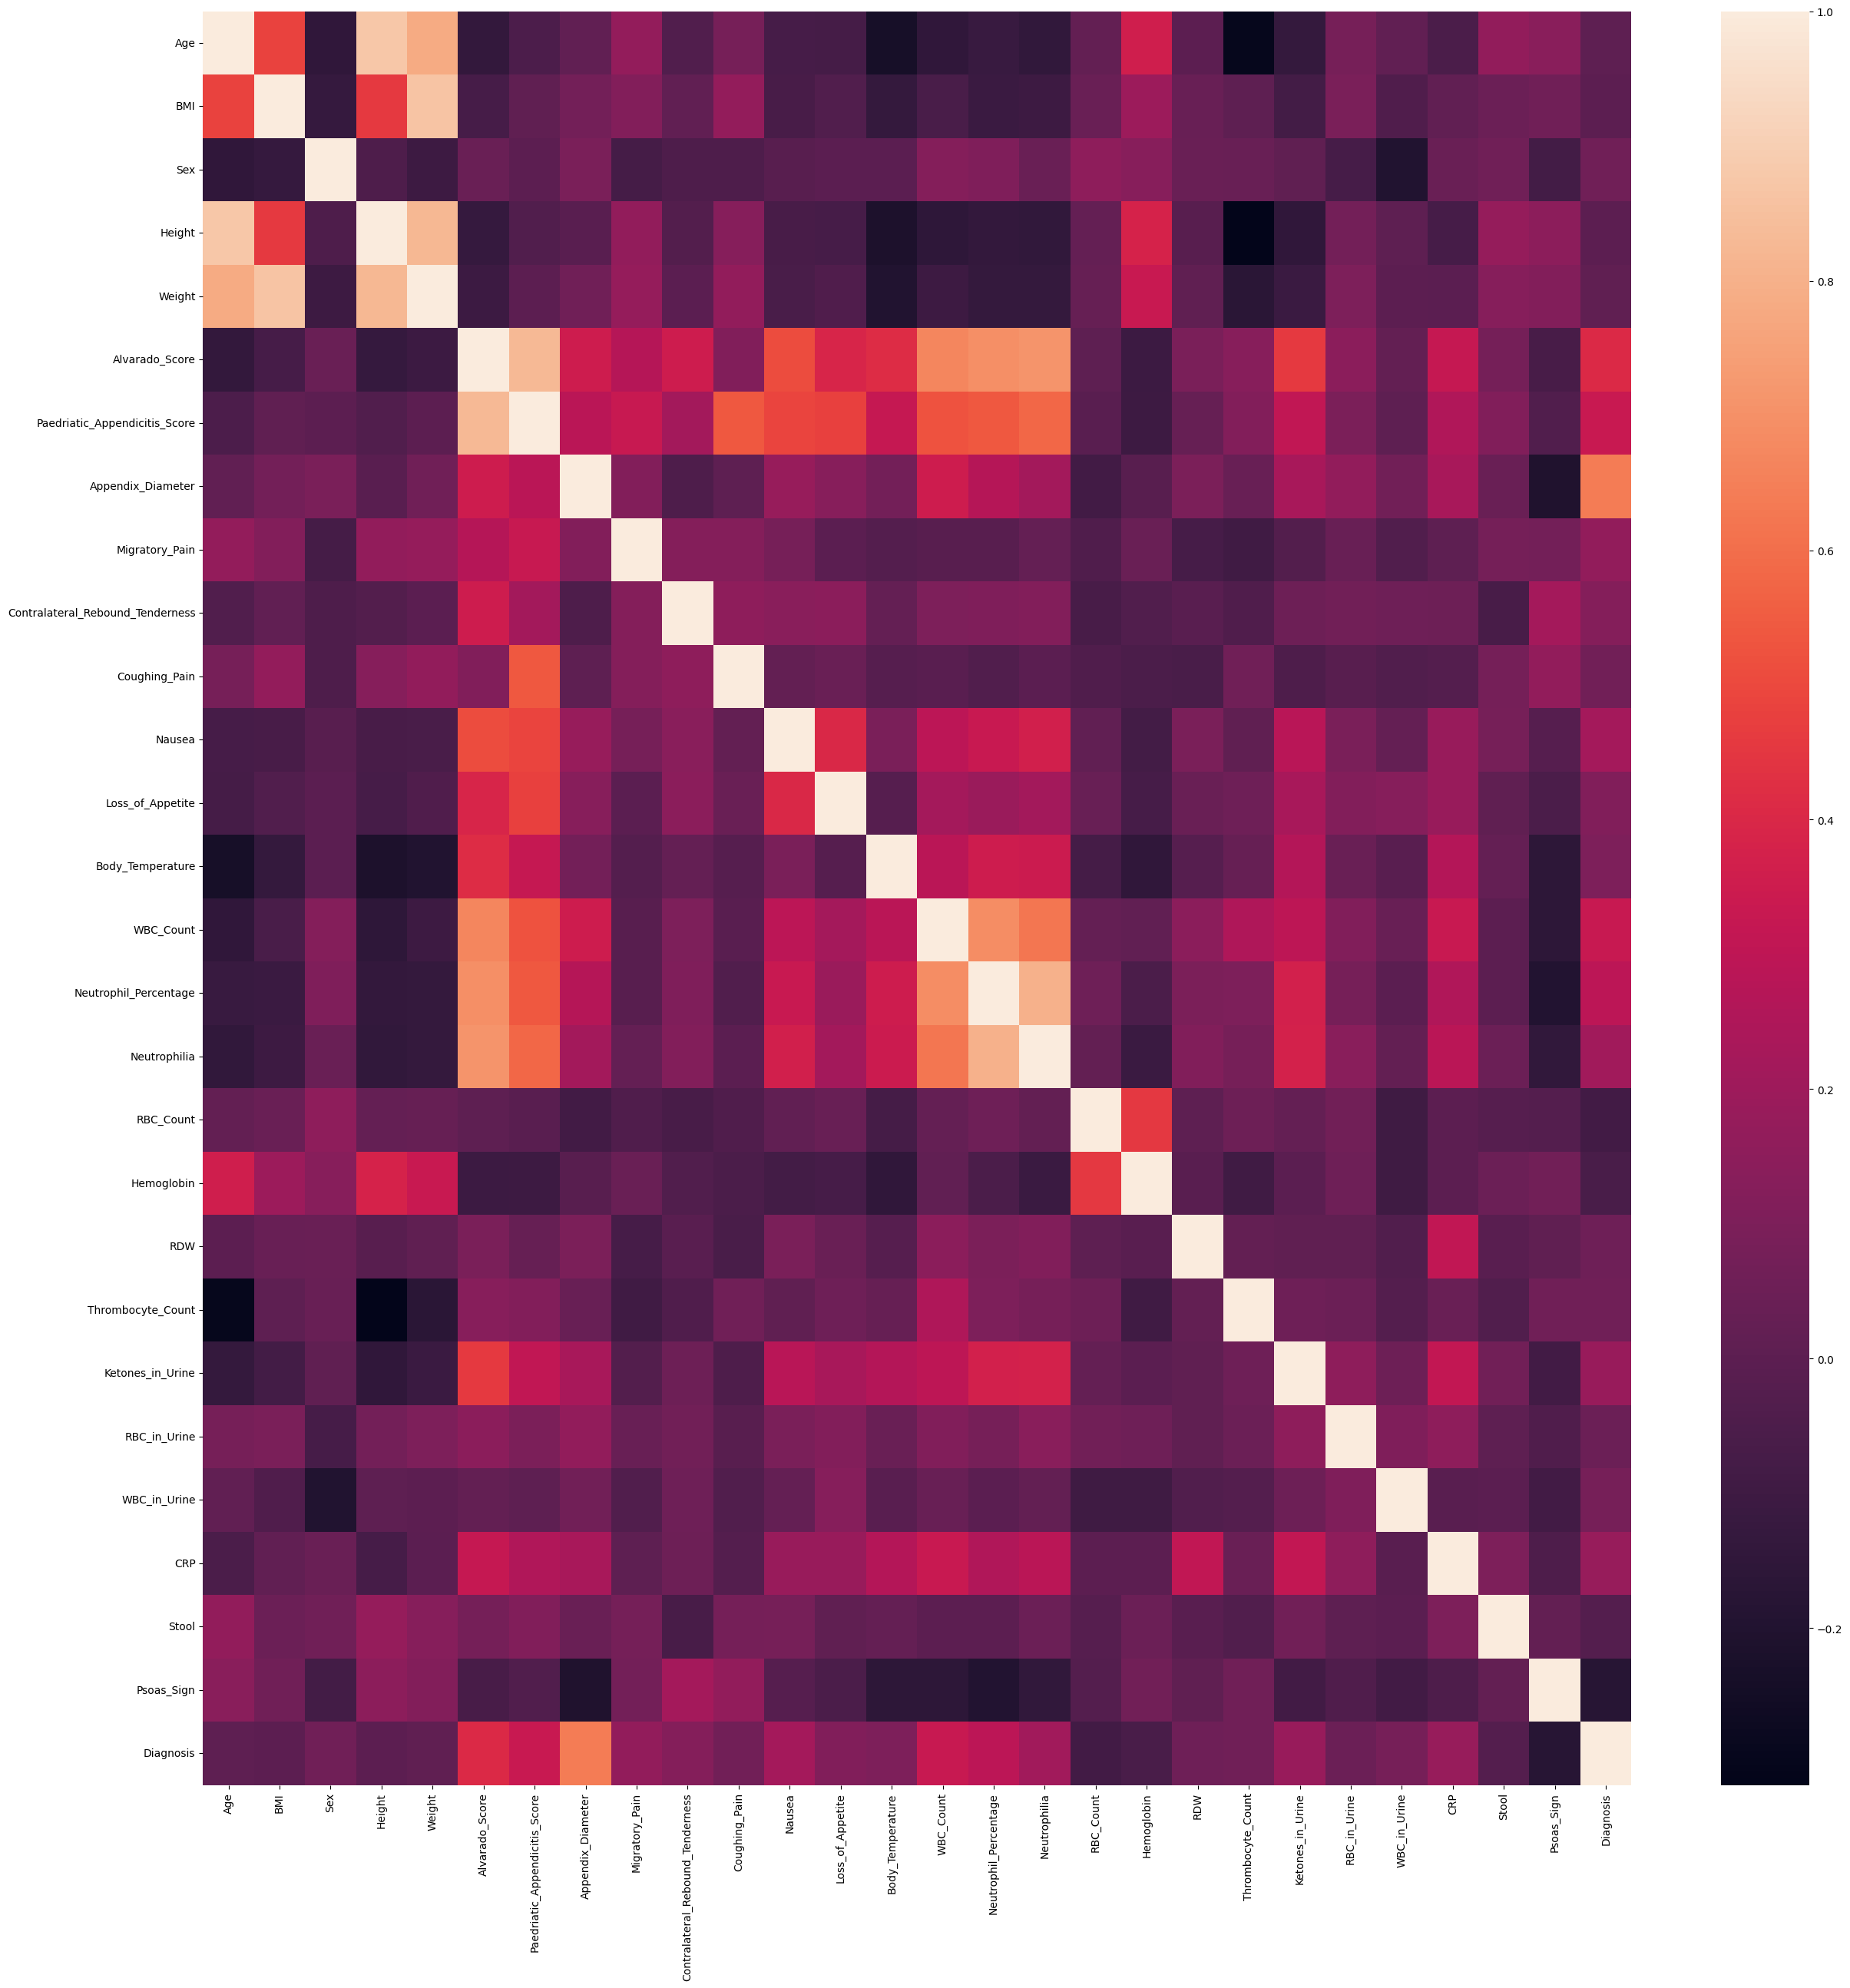

In [76]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)



# correlation of different columns with each other
df.corr()


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


df2["WBC_in_Urine"].value_counts()


# In[23]:


df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


# df.info()


# In[26]:


df2["Sex"].value_counts()


# In[27]:


df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


# df.info()


# In[30]:


# df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


# df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
# df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()


# In[36]:


df2["Nausea"].value_counts(dropna = False)


# In[37]:


df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()


# In[38]:


df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()


# In[40]:


df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()


# In[42]:


df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


# df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
# df2["Dysuria"].value_counts()


# In[51]:


df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)


# In[53]:


# df2["Peritonitis"].value_counts()


# In[54]:


# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)


# In[55]:


# df2["Diagnosis"].corr(df2["Peritonitis"])


# In[56]:


#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)


# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


df2["Psoas_Sign"].value_counts()


# In[60]:


df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


# df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [77]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(289, 28)

In [78]:
y.value_counts()

1    208
0     81
Name: Diagnosis, dtype: int64

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [81]:
x_train.shape

(231, 28)

In [82]:
# y_train.value_counts()

In [83]:
# col
x_train.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Stool', 'Psoas_Sign', 'Free_Fluids'],
      dtype='object')

In [84]:
y_test.value_counts()
y_train.value_counts()

1    171
0     60
Name: Diagnosis, dtype: int64

In [85]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.40      0.19      0.26        21
           1       0.65      0.84      0.73        37

    accuracy                           0.60        58
   macro avg       0.52      0.51      0.49        58
weighted avg       0.56      0.60      0.56        58



In [86]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.05 ± 0.01
TEST_ACCURACY - Mean: 0.70 ± 0.06
TEST_F1 - Mean: 0.80 ± 0.04
TEST_ROC_AUC - Mean: 0.65 ± 0.06
TEST_AVERAGE_PRECISION - Mean: 0.79 ± 0.08
TEST_PRECISION - Mean: 0.77 ± 0.08
TEST_RECALL - Mean: 0.85 ± 0.03


In [87]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7909 ± 0.08


In [88]:
# # Initialize list to store AUPR values for each fold
# aupr_list = []

# # Perform 5-fold cross-validation
# for train_index, test_index in kf.split(X):
#     X_train, X_test = X[train_index], X[test_index]
#     y_train, y_test = y[train_index], y[test_index]

#     # Train the model
#     model.fit(X_train, y_train)

#     # Predict probabilities on the validation set
#     y_proba = model.predict_proba(X_test)

#     # Compute precision and recall
#     precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#     # Compute AUPR for the current fold
#     aupr = auc(recall, precision)

#     # Append AUPR to the list
#     aupr_list.append(aupr)

# # Print AUPR values for each fold
# for fold, aupr in enumerate(aupr_list, start=1):
#     print(f"Fold {fold}: AUPR = {aupr:.4f}")

# # Calculate and print average AUPR over all folds
# avg_aupr = np.mean(aupr_list)
# std_aupr = np.std(aupr_list)
# print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

In [89]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.59      0.62      0.60        21
           1       0.78      0.76      0.77        37

    accuracy                           0.71        58
   macro avg       0.68      0.69      0.69        58
weighted avg       0.71      0.71      0.71        58



In [90]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.02 ± 0.01
TEST_ACCURACY - Mean: 0.74 ± 0.02
TEST_F1 - Mean: 0.80 ± 0.02
TEST_ROC_AUC - Mean: 0.85 ± 0.05
TEST_AVERAGE_PRECISION - Mean: 0.93 ± 0.03
TEST_PRECISION - Mean: 0.90 ± 0.08
TEST_RECALL - Mean: 0.72 ± 0.04


In [91]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9327 ± 0.03


In [92]:
from sklearn.svm import SVC
SVM = SVC()
SVM = SVM.fit(x_train,y_train)
y_pred = SVM.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.64      1.00      0.78        37

    accuracy                           0.64        58
   macro avg       0.32      0.50      0.39        58
weighted avg       0.41      0.64      0.50        58



C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [93]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(SVM,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.72 ± 0.07
TEST_F1 - Mean: 0.83 ± 0.05
TEST_ROC_AUC - Mean: 0.78 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.91 ± 0.04
TEST_PRECISION - Mean: 0.72 ± 0.07
TEST_RECALL - Mean: 1.00 ± 0.00


In [94]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83        21
           1       0.86      1.00      0.92        37

    accuracy                           0.90        58
   macro avg       0.93      0.86      0.88        58
weighted avg       0.91      0.90      0.89        58



In [95]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.02 ± 0.01
TEST_ACCURACY - Mean: 0.93 ± 0.06
TEST_F1 - Mean: 0.95 ± 0.04
TEST_ROC_AUC - Mean: 0.92 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.94 ± 0.06
TEST_PRECISION - Mean: 0.95 ± 0.06
TEST_RECALL - Mean: 0.95 ± 0.06


In [96]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9327 ± 0.05


In [97]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        18
           1       1.00      0.93      0.96        40

    accuracy                           0.95        58
   macro avg       0.93      0.96      0.94        58
weighted avg       0.96      0.95      0.95        58



In [98]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v =='score_time'):
        print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.4560 ± 0.01
SCORE_TIME - Mean: 0.0526 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.05
TEST_F1 - Mean: 0.95 ± 0.04
TEST_ROC_AUC - Mean: 0.98 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [99]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9940 ± 0.01


In [100]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        21
           1       0.95      0.97      0.96        37

    accuracy                           0.95        58
   macro avg       0.95      0.94      0.94        58
weighted avg       0.95      0.95      0.95        58



In [101]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v =='score_time'):
        print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.1128 ± 0.01
SCORE_TIME - Mean: 0.0530 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.04
TEST_F1 - Mean: 0.95 ± 0.03
TEST_ROC_AUC - Mean: 0.98 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.96 ± 0.04
TEST_RECALL - Mean: 0.95 ± 0.05


In [102]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9941 ± 0.01


In [103]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        21
           1       0.95      1.00      0.97        37

    accuracy                           0.97        58
   macro avg       0.97      0.95      0.96        58
weighted avg       0.97      0.97      0.97        58



In [104]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v =='score_time'):
        print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.0694 ± 0.02
SCORE_TIME - Mean: 0.0338 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.05
TEST_F1 - Mean: 0.95 ± 0.04
TEST_ROC_AUC - Mean: 0.97 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.02
TEST_PRECISION - Mean: 0.95 ± 0.04
TEST_RECALL - Mean: 0.95 ± 0.05


In [105]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9879 ± 0.02


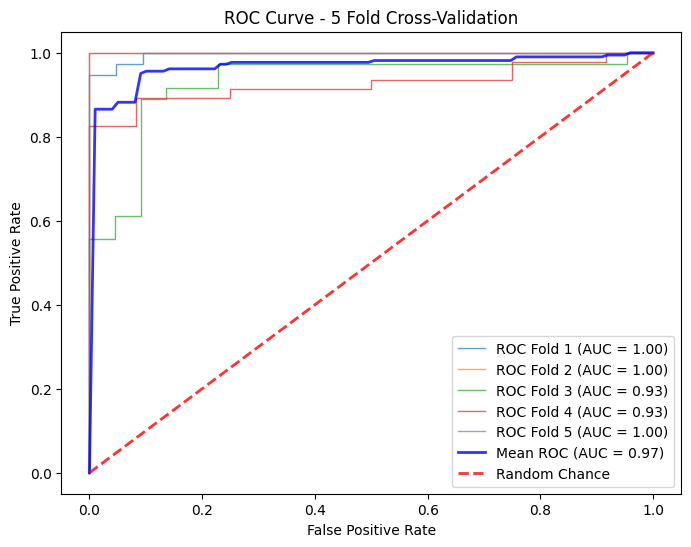

In [106]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [107]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87        21
           1       0.90      0.97      0.94        37

    accuracy                           0.91        58
   macro avg       0.92      0.89      0.90        58
weighted avg       0.92      0.91      0.91        58



In [108]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v =='score_time'):
        print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.2833 ± 0.04
SCORE_TIME - Mean: 0.0565 ± 0.01
TEST_ACCURACY - Mean: 0.93 ± 0.02
TEST_F1 - Mean: 0.95 ± 0.02
TEST_ROC_AUC - Mean: 0.97 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.94 ± 0.03
TEST_RECALL - Mean: 0.96 ± 0.04


In [109]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9886 ± 0.01


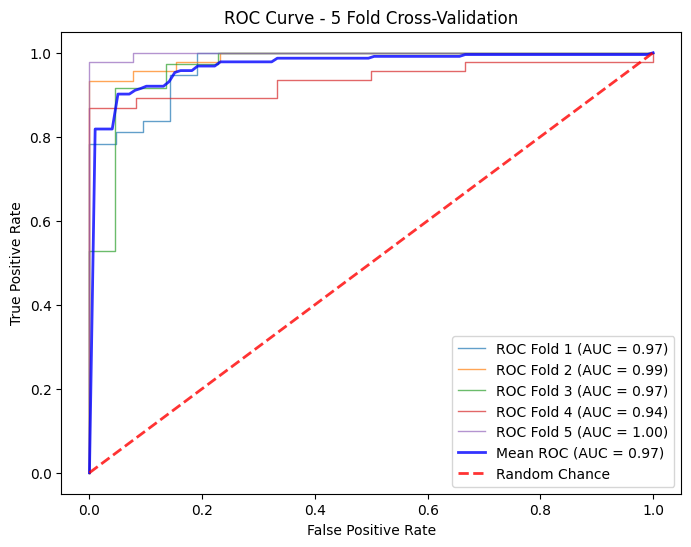

In [110]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [111]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        21
           1       0.97      0.97      0.97        37

    accuracy                           0.97        58
   macro avg       0.96      0.96      0.96        58
weighted avg       0.97      0.97      0.97        58



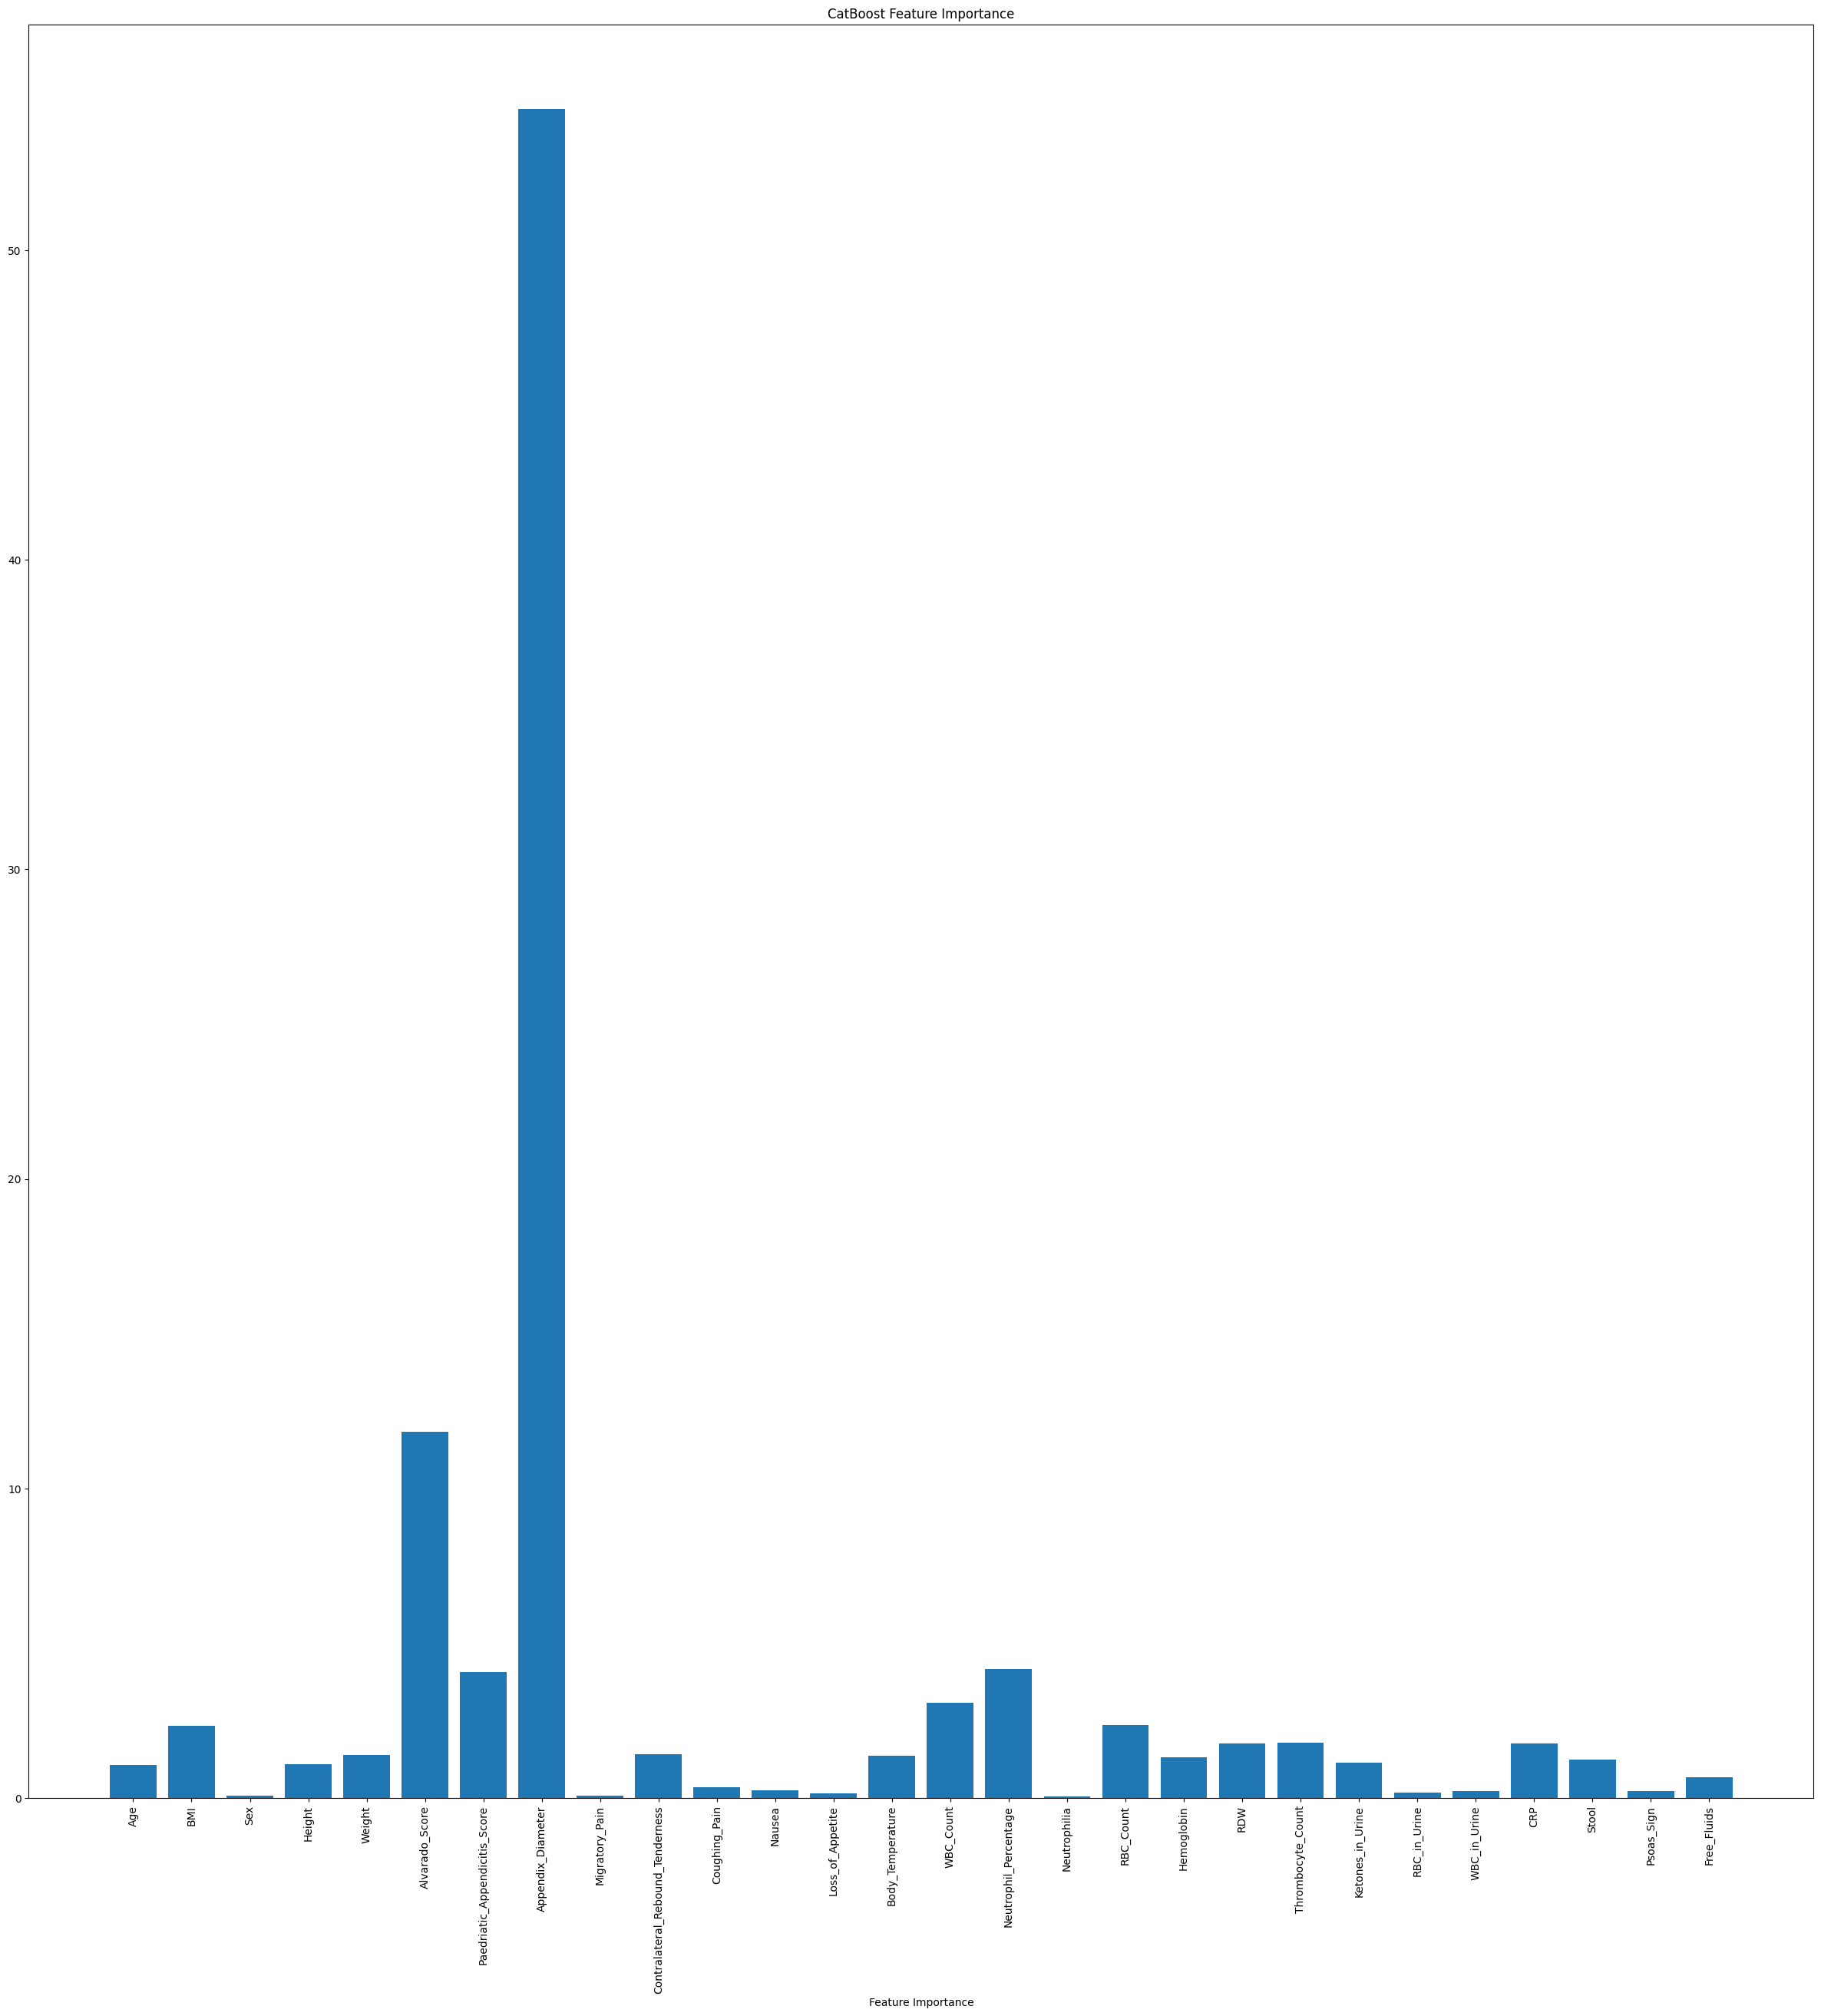

In [112]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = x_train.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [113]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v == 'fit_time' or v =='score_time'):
        print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6817864	total: 6.25ms	remaining: 9.37s
1:	learn: 0.6697116	total: 12.5ms	remaining: 9.36s
2:	learn: 0.6556827	total: 16.9ms	remaining: 8.44s
3:	learn: 0.6471612	total: 22.2ms	remaining: 8.29s
4:	learn: 0.6297578	total: 26.7ms	remaining: 7.99s
5:	learn: 0.6211585	total: 31.3ms	remaining: 7.79s
6:	learn: 0.6075377	total: 34.6ms	remaining: 7.38s
7:	learn: 0.5946127	total: 37.7ms	remaining: 7.02s
8:	learn: 0.5835353	total: 41.4ms	remaining: 6.86s
9:	learn: 0.5741091	total: 44.6ms	remaining: 6.64s
10:	learn: 0.5617358	total: 48.7ms	remaining: 6.59s
11:	learn: 0.5515986	total: 51.5ms	remaining: 6.38s
12:	learn: 0.5389668	total: 54.4ms	remaining: 6.22s
13:	learn: 0.5307900	total: 58.8ms	remaining: 6.24s
14:	learn: 0.5213686	total: 62.7ms	remaining: 6.2s
15:	learn: 0.5115063	total: 67.5ms	remaining: 6.26s
16:	learn: 0.5049608	total: 71.6ms	remaining: 6.25s
17:	learn: 0.4932740	total: 75.3ms	remaining: 6.2s
18:	learn: 0.4832654	total: 80.6ms	remaining: 6.28s
19:	learn: 0.4779093	tot

179:	learn: 0.1045976	total: 979ms	remaining: 7.18s
180:	learn: 0.1038008	total: 985ms	remaining: 7.18s
181:	learn: 0.1033492	total: 991ms	remaining: 7.18s
182:	learn: 0.1030612	total: 997ms	remaining: 7.17s
183:	learn: 0.1027285	total: 1s	remaining: 7.17s
184:	learn: 0.1024121	total: 1.01s	remaining: 7.17s
185:	learn: 0.1018678	total: 1.01s	remaining: 7.17s
186:	learn: 0.1012060	total: 1.02s	remaining: 7.17s
187:	learn: 0.1008711	total: 1.03s	remaining: 7.17s
188:	learn: 0.1003591	total: 1.03s	remaining: 7.16s
189:	learn: 0.0998690	total: 1.04s	remaining: 7.16s
190:	learn: 0.0995651	total: 1.04s	remaining: 7.16s
191:	learn: 0.0991229	total: 1.05s	remaining: 7.16s
192:	learn: 0.0988349	total: 1.06s	remaining: 7.17s
193:	learn: 0.0983153	total: 1.06s	remaining: 7.16s
194:	learn: 0.0978520	total: 1.07s	remaining: 7.16s
195:	learn: 0.0974025	total: 1.08s	remaining: 7.17s
196:	learn: 0.0971595	total: 1.08s	remaining: 7.16s
197:	learn: 0.0967716	total: 1.09s	remaining: 7.17s
198:	learn: 0.0

358:	learn: 0.0531248	total: 1.98s	remaining: 6.29s
359:	learn: 0.0528357	total: 1.99s	remaining: 6.29s
360:	learn: 0.0526965	total: 1.99s	remaining: 6.28s
361:	learn: 0.0526732	total: 2s	remaining: 6.28s
362:	learn: 0.0524111	total: 2s	remaining: 6.28s
363:	learn: 0.0522092	total: 2.01s	remaining: 6.27s
364:	learn: 0.0520753	total: 2.01s	remaining: 6.26s
365:	learn: 0.0518771	total: 2.02s	remaining: 6.25s
366:	learn: 0.0518330	total: 2.02s	remaining: 6.25s
367:	learn: 0.0517729	total: 2.03s	remaining: 6.24s
368:	learn: 0.0514999	total: 2.04s	remaining: 6.24s
369:	learn: 0.0513726	total: 2.04s	remaining: 6.23s
370:	learn: 0.0511638	total: 2.04s	remaining: 6.22s
371:	learn: 0.0509820	total: 2.05s	remaining: 6.22s
372:	learn: 0.0508127	total: 2.06s	remaining: 6.21s
373:	learn: 0.0506447	total: 2.06s	remaining: 6.21s
374:	learn: 0.0504761	total: 2.07s	remaining: 6.2s
375:	learn: 0.0502148	total: 2.07s	remaining: 6.19s
376:	learn: 0.0500867	total: 2.08s	remaining: 6.19s
377:	learn: 0.04981

538:	learn: 0.0309253	total: 2.96s	remaining: 5.28s
539:	learn: 0.0309040	total: 2.96s	remaining: 5.27s
540:	learn: 0.0307866	total: 2.97s	remaining: 5.27s
541:	learn: 0.0307009	total: 2.98s	remaining: 5.26s
542:	learn: 0.0305642	total: 2.98s	remaining: 5.26s
543:	learn: 0.0305035	total: 2.99s	remaining: 5.26s
544:	learn: 0.0304088	total: 3s	remaining: 5.26s
545:	learn: 0.0302331	total: 3.01s	remaining: 5.26s
546:	learn: 0.0301676	total: 3.01s	remaining: 5.25s
547:	learn: 0.0300651	total: 3.02s	remaining: 5.25s
548:	learn: 0.0300168	total: 3.03s	remaining: 5.24s
549:	learn: 0.0299117	total: 3.03s	remaining: 5.24s
550:	learn: 0.0298078	total: 3.04s	remaining: 5.23s
551:	learn: 0.0297241	total: 3.04s	remaining: 5.23s
552:	learn: 0.0295604	total: 3.05s	remaining: 5.22s
553:	learn: 0.0295264	total: 3.05s	remaining: 5.22s
554:	learn: 0.0295024	total: 3.06s	remaining: 5.21s
555:	learn: 0.0294530	total: 3.06s	remaining: 5.2s
556:	learn: 0.0293432	total: 3.07s	remaining: 5.2s
557:	learn: 0.029

709:	learn: 0.0203955	total: 3.94s	remaining: 4.38s
710:	learn: 0.0203910	total: 3.94s	remaining: 4.37s
711:	learn: 0.0202973	total: 3.94s	remaining: 4.37s
712:	learn: 0.0202058	total: 3.95s	remaining: 4.36s
713:	learn: 0.0202022	total: 3.95s	remaining: 4.35s
714:	learn: 0.0201914	total: 3.95s	remaining: 4.34s
715:	learn: 0.0201879	total: 3.96s	remaining: 4.33s
716:	learn: 0.0201570	total: 3.96s	remaining: 4.32s
717:	learn: 0.0201536	total: 3.96s	remaining: 4.32s
718:	learn: 0.0200979	total: 3.97s	remaining: 4.31s
719:	learn: 0.0200944	total: 3.97s	remaining: 4.3s
720:	learn: 0.0200552	total: 3.98s	remaining: 4.3s
721:	learn: 0.0200516	total: 3.98s	remaining: 4.29s
722:	learn: 0.0200046	total: 3.98s	remaining: 4.28s
723:	learn: 0.0199585	total: 3.98s	remaining: 4.27s
724:	learn: 0.0199545	total: 3.99s	remaining: 4.27s
725:	learn: 0.0198986	total: 3.99s	remaining: 4.26s
726:	learn: 0.0198116	total: 4s	remaining: 4.25s
727:	learn: 0.0198081	total: 4s	remaining: 4.25s
728:	learn: 0.019804

...

622:	learn: 0.0219967	total: 3.95s	remaining: 5.56s
623:	learn: 0.0219082	total: 3.95s	remaining: 5.55s
624:	learn: 0.0218242	total: 3.96s	remaining: 5.54s
625:	learn: 0.0218129	total: 3.97s	remaining: 5.54s
626:	learn: 0.0217908	total: 3.97s	remaining: 5.53s
627:	learn: 0.0217764	total: 3.98s	remaining: 5.53s
628:	learn: 0.0217662	total: 3.99s	remaining: 5.52s
629:	learn: 0.0217630	total: 4s	remaining: 5.52s
630:	learn: 0.0217519	total: 4s	remaining: 5.51s
631:	learn: 0.0217033	total: 4.01s	remaining: 5.5s
632:	learn: 0.0216282	total: 4.01s	remaining: 5.5s
633:	learn: 0.0216120	total: 4.02s	remaining: 5.49s
634:	learn: 0.0215704	total: 4.02s	remaining: 5.48s
635:	learn: 0.0215498	total: 4.03s	remaining: 5.47s
636:	learn: 0.0215360	total: 4.04s	remaining: 5.47s
637:	learn: 0.0215253	total: 4.04s	remaining: 5.46s
638:	learn: 0.0214007	total: 4.05s	remaining: 5.46s
639:	learn: 0.0213828	total: 4.05s	remaining: 5.45s
640:	learn: 0.0212956	total: 4.06s	remaining: 5.44s
641:	learn: 0.021205

783:	learn: 0.0171046	total: 4.93s	remaining: 4.5s
784:	learn: 0.0170275	total: 4.94s	remaining: 4.5s
785:	learn: 0.0170219	total: 4.94s	remaining: 4.49s
786:	learn: 0.0169604	total: 4.95s	remaining: 4.48s
787:	learn: 0.0169318	total: 4.95s	remaining: 4.47s
788:	learn: 0.0168711	total: 4.96s	remaining: 4.47s
789:	learn: 0.0168507	total: 4.96s	remaining: 4.46s
790:	learn: 0.0168468	total: 4.97s	remaining: 4.45s
791:	learn: 0.0168399	total: 4.97s	remaining: 4.45s
792:	learn: 0.0168348	total: 4.98s	remaining: 4.44s
793:	learn: 0.0167614	total: 4.98s	remaining: 4.43s
794:	learn: 0.0166889	total: 4.99s	remaining: 4.42s
795:	learn: 0.0166851	total: 4.99s	remaining: 4.42s
796:	learn: 0.0166229	total: 5s	remaining: 4.41s
797:	learn: 0.0165639	total: 5s	remaining: 4.4s
798:	learn: 0.0165463	total: 5.01s	remaining: 4.39s
799:	learn: 0.0164741	total: 5.01s	remaining: 4.38s
800:	learn: 0.0164148	total: 5.01s	remaining: 4.38s
801:	learn: 0.0164086	total: 5.02s	remaining: 4.37s
802:	learn: 0.0164054

973:	learn: 0.0119329	total: 6.1s	remaining: 3.29s
974:	learn: 0.0118869	total: 6.11s	remaining: 3.29s
975:	learn: 0.0118519	total: 6.11s	remaining: 3.28s
976:	learn: 0.0118461	total: 6.11s	remaining: 3.27s
977:	learn: 0.0118335	total: 6.12s	remaining: 3.27s
978:	learn: 0.0118191	total: 6.12s	remaining: 3.26s
979:	learn: 0.0117868	total: 6.13s	remaining: 3.25s
980:	learn: 0.0117564	total: 6.14s	remaining: 3.25s
981:	learn: 0.0117535	total: 6.14s	remaining: 3.24s
982:	learn: 0.0117478	total: 6.15s	remaining: 3.23s
983:	learn: 0.0117128	total: 6.15s	remaining: 3.23s
984:	learn: 0.0117049	total: 6.16s	remaining: 3.22s
985:	learn: 0.0117010	total: 6.16s	remaining: 3.21s
986:	learn: 0.0116955	total: 6.16s	remaining: 3.2s
987:	learn: 0.0116763	total: 6.17s	remaining: 3.2s
988:	learn: 0.0116556	total: 6.17s	remaining: 3.19s
989:	learn: 0.0116353	total: 6.18s	remaining: 3.18s
990:	learn: 0.0116325	total: 6.18s	remaining: 3.18s
991:	learn: 0.0115910	total: 6.19s	remaining: 3.17s
992:	learn: 0.0

1159:	learn: 0.0089779	total: 7.28s	remaining: 2.13s
1160:	learn: 0.0089626	total: 7.29s	remaining: 2.13s
1161:	learn: 0.0089555	total: 7.29s	remaining: 2.12s
1162:	learn: 0.0089538	total: 7.3s	remaining: 2.12s
1163:	learn: 0.0089288	total: 7.3s	remaining: 2.11s
1164:	learn: 0.0089270	total: 7.31s	remaining: 2.1s
1165:	learn: 0.0089169	total: 7.32s	remaining: 2.1s
1166:	learn: 0.0088897	total: 7.32s	remaining: 2.09s
1167:	learn: 0.0088880	total: 7.33s	remaining: 2.08s
1168:	learn: 0.0088695	total: 7.33s	remaining: 2.08s
1169:	learn: 0.0088637	total: 7.34s	remaining: 2.07s
1170:	learn: 0.0088496	total: 7.35s	remaining: 2.06s
1171:	learn: 0.0088346	total: 7.35s	remaining: 2.06s
1172:	learn: 0.0088198	total: 7.36s	remaining: 2.05s
1173:	learn: 0.0088158	total: 7.37s	remaining: 2.04s
1174:	learn: 0.0088015	total: 7.37s	remaining: 2.04s
1175:	learn: 0.0087868	total: 7.38s	remaining: 2.03s
1176:	learn: 0.0087690	total: 7.38s	remaining: 2.03s
1177:	learn: 0.0087447	total: 7.39s	remaining: 2.0

1347:	learn: 0.0070916	total: 8.47s	remaining: 955ms
1348:	learn: 0.0070781	total: 8.47s	remaining: 948ms
1349:	learn: 0.0070756	total: 8.48s	remaining: 942ms
1350:	learn: 0.0070589	total: 8.48s	remaining: 935ms
1351:	learn: 0.0070581	total: 8.49s	remaining: 929ms
1352:	learn: 0.0070517	total: 8.49s	remaining: 923ms
1353:	learn: 0.0070483	total: 8.5s	remaining: 916ms
1354:	learn: 0.0070456	total: 8.5s	remaining: 910ms
1355:	learn: 0.0070432	total: 8.51s	remaining: 904ms
1356:	learn: 0.0070370	total: 8.51s	remaining: 897ms
1357:	learn: 0.0070254	total: 8.52s	remaining: 891ms
1358:	learn: 0.0070173	total: 8.53s	remaining: 885ms
1359:	learn: 0.0070144	total: 8.53s	remaining: 878ms
1360:	learn: 0.0070077	total: 8.54s	remaining: 872ms
1361:	learn: 0.0069915	total: 8.54s	remaining: 866ms
1362:	learn: 0.0069904	total: 8.55s	remaining: 859ms
1363:	learn: 0.0069839	total: 8.55s	remaining: 853ms
1364:	learn: 0.0069812	total: 8.56s	remaining: 847ms
1365:	learn: 0.0069719	total: 8.57s	remaining: 8

In [114]:
# calculating auc for 5 folds : lagaing dimaaaaag

from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
# scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)
score = cross_val_score(model,X,y,scoring = 'roc_auc')

print(score)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6810917	total: 7.69ms	remaining: 11.5s
1:	learn: 0.6680765	total: 15.6ms	remaining: 11.7s
2:	learn: 0.6538680	total: 22.6ms	remaining: 11.3s
3:	learn: 0.6440046	total: 29.2ms	remaining: 10.9s
4:	learn: 0.6266358	total: 35.8ms	remaining: 10.7s
5:	learn: 0.6167727	total: 42.8ms	remaining: 10.7s
6:	learn: 0.6035025	total: 50.4ms	remaining: 10.8s
7:	learn: 0.5935701	total: 57.6ms	remaining: 10.7s
8:	learn: 0.5833968	total: 63.7ms	remaining: 10.6s
9:	learn: 0.5744419	total: 70.4ms	remaining: 10.5s
10:	learn: 0.5622586	total: 77.1ms	remaining: 10.4s
11:	learn: 0.5500163	total: 83.1ms	remaining: 10.3s
12:	learn: 0.5378360	total: 90.8ms	remaining: 10.4s
13:	learn: 0.5289535	total: 96.9ms	remaining: 10.3s
14:	learn: 0.5186738	total: 104ms	remaining: 10.3s
15:	learn: 0.5131673	total: 108ms	remaining: 10s
16:	learn: 0.5061929	total: 114ms	remaining: 9.91s
17:	learn: 0.4988330	total: 118ms	remaining: 9.72s
18:	learn: 0.4909233	total: 124ms	remaining: 9.66s
19:	learn: 0.4846575	total: 1

166:	learn: 0.1160226	total: 980ms	remaining: 7.82s
167:	learn: 0.1149808	total: 986ms	remaining: 7.82s
168:	learn: 0.1145656	total: 992ms	remaining: 7.81s
169:	learn: 0.1135335	total: 997ms	remaining: 7.8s
170:	learn: 0.1131665	total: 1s	remaining: 7.78s
171:	learn: 0.1126379	total: 1.01s	remaining: 7.77s
172:	learn: 0.1121411	total: 1.01s	remaining: 7.76s
173:	learn: 0.1116856	total: 1.02s	remaining: 7.77s
174:	learn: 0.1113195	total: 1.02s	remaining: 7.75s
175:	learn: 0.1108738	total: 1.03s	remaining: 7.74s
176:	learn: 0.1102948	total: 1.03s	remaining: 7.74s
177:	learn: 0.1094316	total: 1.04s	remaining: 7.73s
178:	learn: 0.1087744	total: 1.04s	remaining: 7.71s
179:	learn: 0.1079892	total: 1.05s	remaining: 7.7s
180:	learn: 0.1070679	total: 1.05s	remaining: 7.69s
181:	learn: 0.1061935	total: 1.06s	remaining: 7.67s
182:	learn: 0.1058331	total: 1.06s	remaining: 7.65s
183:	learn: 0.1053444	total: 1.07s	remaining: 7.64s
184:	learn: 0.1049611	total: 1.07s	remaining: 7.63s
185:	learn: 0.104

329:	learn: 0.0594058	total: 1.98s	remaining: 7s
330:	learn: 0.0590675	total: 1.98s	remaining: 7s
331:	learn: 0.0588615	total: 1.99s	remaining: 6.99s
332:	learn: 0.0586787	total: 1.99s	remaining: 6.98s
333:	learn: 0.0585688	total: 2s	remaining: 6.98s
334:	learn: 0.0585334	total: 2s	remaining: 6.97s
335:	learn: 0.0583314	total: 2.01s	remaining: 6.96s
336:	learn: 0.0580426	total: 2.01s	remaining: 6.95s
337:	learn: 0.0576754	total: 2.02s	remaining: 6.94s
338:	learn: 0.0575639	total: 2.02s	remaining: 6.93s
339:	learn: 0.0573190	total: 2.03s	remaining: 6.92s
340:	learn: 0.0570495	total: 2.03s	remaining: 6.92s
341:	learn: 0.0569208	total: 2.04s	remaining: 6.92s
342:	learn: 0.0567870	total: 2.05s	remaining: 6.91s
343:	learn: 0.0565022	total: 2.05s	remaining: 6.9s
344:	learn: 0.0562842	total: 2.06s	remaining: 6.9s
345:	learn: 0.0561137	total: 2.07s	remaining: 6.9s
346:	learn: 0.0559269	total: 2.07s	remaining: 6.89s
347:	learn: 0.0558545	total: 2.08s	remaining: 6.88s
348:	learn: 0.0556775	total

489:	learn: 0.0354704	total: 2.94s	remaining: 6.07s
490:	learn: 0.0354327	total: 2.95s	remaining: 6.06s
491:	learn: 0.0353659	total: 2.96s	remaining: 6.05s
492:	learn: 0.0352486	total: 2.96s	remaining: 6.04s
493:	learn: 0.0351656	total: 2.96s	remaining: 6.04s
494:	learn: 0.0350057	total: 2.97s	remaining: 6.03s
495:	learn: 0.0349317	total: 2.98s	remaining: 6.02s
496:	learn: 0.0348026	total: 2.98s	remaining: 6.02s
497:	learn: 0.0346252	total: 2.99s	remaining: 6.01s
498:	learn: 0.0344919	total: 2.99s	remaining: 6.01s
499:	learn: 0.0344501	total: 3s	remaining: 6s
500:	learn: 0.0342370	total: 3.01s	remaining: 5.99s
501:	learn: 0.0342072	total: 3.01s	remaining: 5.99s
502:	learn: 0.0340935	total: 3.02s	remaining: 5.98s
503:	learn: 0.0339575	total: 3.02s	remaining: 5.98s
504:	learn: 0.0338601	total: 3.03s	remaining: 5.97s
505:	learn: 0.0337152	total: 3.04s	remaining: 5.97s
506:	learn: 0.0336717	total: 3.04s	remaining: 5.96s
507:	learn: 0.0336015	total: 3.05s	remaining: 5.96s
508:	learn: 0.0335

660:	learn: 0.0213856	total: 3.94s	remaining: 5s
661:	learn: 0.0213460	total: 3.95s	remaining: 5s
662:	learn: 0.0213129	total: 3.96s	remaining: 5s
663:	learn: 0.0212462	total: 3.96s	remaining: 4.99s
664:	learn: 0.0212068	total: 3.97s	remaining: 4.99s
665:	learn: 0.0211590	total: 3.98s	remaining: 4.98s
666:	learn: 0.0211257	total: 3.98s	remaining: 4.97s
667:	learn: 0.0211198	total: 3.99s	remaining: 4.97s
668:	learn: 0.0210722	total: 4s	remaining: 4.96s
669:	learn: 0.0210331	total: 4s	remaining: 4.96s
670:	learn: 0.0209907	total: 4.01s	remaining: 4.95s
671:	learn: 0.0209190	total: 4.01s	remaining: 4.95s
672:	learn: 0.0208567	total: 4.02s	remaining: 4.94s
673:	learn: 0.0208282	total: 4.03s	remaining: 4.93s
674:	learn: 0.0207800	total: 4.03s	remaining: 4.93s
675:	learn: 0.0207480	total: 4.04s	remaining: 4.92s
676:	learn: 0.0206734	total: 4.05s	remaining: 4.92s
677:	learn: 0.0206309	total: 4.05s	remaining: 4.91s
678:	learn: 0.0205274	total: 4.06s	remaining: 4.91s
679:	learn: 0.0204656	total

...

702:	learn: 0.0197571	total: 4.13s	remaining: 4.68s
703:	learn: 0.0197489	total: 4.14s	remaining: 4.68s
704:	learn: 0.0196511	total: 4.15s	remaining: 4.67s
705:	learn: 0.0196291	total: 4.15s	remaining: 4.67s
706:	learn: 0.0195685	total: 4.16s	remaining: 4.66s
707:	learn: 0.0194817	total: 4.16s	remaining: 4.66s
708:	learn: 0.0194694	total: 4.17s	remaining: 4.65s
709:	learn: 0.0193674	total: 4.17s	remaining: 4.64s
710:	learn: 0.0192832	total: 4.18s	remaining: 4.64s
711:	learn: 0.0192032	total: 4.19s	remaining: 4.63s
712:	learn: 0.0191794	total: 4.19s	remaining: 4.63s
713:	learn: 0.0191649	total: 4.2s	remaining: 4.62s
714:	learn: 0.0191216	total: 4.2s	remaining: 4.61s
715:	learn: 0.0190728	total: 4.21s	remaining: 4.61s
716:	learn: 0.0189925	total: 4.21s	remaining: 4.6s
717:	learn: 0.0189472	total: 4.22s	remaining: 4.6s
718:	learn: 0.0189396	total: 4.23s	remaining: 4.59s
719:	learn: 0.0189322	total: 4.23s	remaining: 4.58s
720:	learn: 0.0188957	total: 4.24s	remaining: 4.58s
721:	learn: 0.01

869:	learn: 0.0143017	total: 5.11s	remaining: 3.7s
870:	learn: 0.0142938	total: 5.12s	remaining: 3.7s
871:	learn: 0.0142895	total: 5.12s	remaining: 3.69s
872:	learn: 0.0142419	total: 5.13s	remaining: 3.68s
873:	learn: 0.0142305	total: 5.13s	remaining: 3.68s
874:	learn: 0.0141852	total: 5.14s	remaining: 3.67s
875:	learn: 0.0141805	total: 5.15s	remaining: 3.67s
876:	learn: 0.0141577	total: 5.15s	remaining: 3.66s
877:	learn: 0.0141203	total: 5.16s	remaining: 3.65s
878:	learn: 0.0140924	total: 5.16s	remaining: 3.65s
879:	learn: 0.0140621	total: 5.17s	remaining: 3.64s
880:	learn: 0.0140598	total: 5.17s	remaining: 3.64s
881:	learn: 0.0140236	total: 5.18s	remaining: 3.63s
882:	learn: 0.0139756	total: 5.19s	remaining: 3.62s
883:	learn: 0.0139318	total: 5.19s	remaining: 3.62s
884:	learn: 0.0139025	total: 5.2s	remaining: 3.61s
885:	learn: 0.0138670	total: 5.2s	remaining: 3.6s
886:	learn: 0.0138179	total: 5.21s	remaining: 3.6s
887:	learn: 0.0137953	total: 5.21s	remaining: 3.59s
888:	learn: 0.0137

1034:	learn: 0.0112293	total: 6.09s	remaining: 2.74s
1035:	learn: 0.0112270	total: 6.1s	remaining: 2.73s
1036:	learn: 0.0112248	total: 6.1s	remaining: 2.73s
1037:	learn: 0.0112054	total: 6.11s	remaining: 2.72s
1038:	learn: 0.0111736	total: 6.12s	remaining: 2.71s
1039:	learn: 0.0111716	total: 6.12s	remaining: 2.71s
1040:	learn: 0.0111693	total: 6.13s	remaining: 2.7s
1041:	learn: 0.0111673	total: 6.14s	remaining: 2.7s
1042:	learn: 0.0111650	total: 6.14s	remaining: 2.69s
1043:	learn: 0.0111629	total: 6.15s	remaining: 2.69s
1044:	learn: 0.0111615	total: 6.15s	remaining: 2.68s
1045:	learn: 0.0111378	total: 6.16s	remaining: 2.67s
1046:	learn: 0.0111065	total: 6.16s	remaining: 2.67s
1047:	learn: 0.0110887	total: 6.17s	remaining: 2.66s
1048:	learn: 0.0110865	total: 6.17s	remaining: 2.65s
1049:	learn: 0.0110850	total: 6.18s	remaining: 2.65s
1050:	learn: 0.0110836	total: 6.19s	remaining: 2.64s
1051:	learn: 0.0110821	total: 6.19s	remaining: 2.64s
1052:	learn: 0.0110629	total: 6.2s	remaining: 2.63

1204:	learn: 0.0095423	total: 7.08s	remaining: 1.73s
1205:	learn: 0.0095197	total: 7.08s	remaining: 1.73s
1206:	learn: 0.0095187	total: 7.09s	remaining: 1.72s
1207:	learn: 0.0095167	total: 7.1s	remaining: 1.72s
1208:	learn: 0.0095146	total: 7.1s	remaining: 1.71s
1209:	learn: 0.0094967	total: 7.11s	remaining: 1.7s
1210:	learn: 0.0094951	total: 7.12s	remaining: 1.7s
1211:	learn: 0.0094709	total: 7.12s	remaining: 1.69s
1212:	learn: 0.0094698	total: 7.13s	remaining: 1.69s
1213:	learn: 0.0094686	total: 7.13s	remaining: 1.68s
1214:	learn: 0.0094666	total: 7.14s	remaining: 1.67s
1215:	learn: 0.0094486	total: 7.14s	remaining: 1.67s
1216:	learn: 0.0094417	total: 7.15s	remaining: 1.66s
1217:	learn: 0.0094402	total: 7.15s	remaining: 1.66s
1218:	learn: 0.0094387	total: 7.16s	remaining: 1.65s
1219:	learn: 0.0094377	total: 7.17s	remaining: 1.64s
1220:	learn: 0.0094361	total: 7.17s	remaining: 1.64s
1221:	learn: 0.0094347	total: 7.18s	remaining: 1.63s
1222:	learn: 0.0094299	total: 7.18s	remaining: 1.6

1373:	learn: 0.0085603	total: 8.07s	remaining: 740ms
1374:	learn: 0.0085591	total: 8.07s	remaining: 734ms
1375:	learn: 0.0085582	total: 8.08s	remaining: 728ms
1376:	learn: 0.0085571	total: 8.08s	remaining: 722ms
1377:	learn: 0.0085562	total: 8.09s	remaining: 716ms
1378:	learn: 0.0085409	total: 8.1s	remaining: 710ms
1379:	learn: 0.0085200	total: 8.13s	remaining: 707ms
1380:	learn: 0.0085071	total: 8.13s	remaining: 701ms
1381:	learn: 0.0085060	total: 8.14s	remaining: 695ms
1382:	learn: 0.0085052	total: 8.15s	remaining: 689ms
1383:	learn: 0.0085040	total: 8.15s	remaining: 683ms
1384:	learn: 0.0084890	total: 8.15s	remaining: 677ms
1385:	learn: 0.0084882	total: 8.16s	remaining: 671ms
1386:	learn: 0.0084874	total: 8.17s	remaining: 665ms
1387:	learn: 0.0084865	total: 8.17s	remaining: 659ms
1388:	learn: 0.0084740	total: 8.18s	remaining: 653ms
1389:	learn: 0.0084731	total: 8.18s	remaining: 647ms
1390:	learn: 0.0084722	total: 8.19s	remaining: 642ms
1391:	learn: 0.0084713	total: 8.19s	remaining: 

In [ ]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


0:	learn: 0.6891636	total: 6.59ms	remaining: 9.88s
1:	learn: 0.6865309	total: 13.5ms	remaining: 10.1s
2:	learn: 0.6834560	total: 20.4ms	remaining: 10.2s
3:	learn: 0.6809164	total: 26.3ms	remaining: 9.85s
4:	learn: 0.6769902	total: 33.5ms	remaining: 10s
5:	learn: 0.6729000	total: 39.6ms	remaining: 9.87s
6:	learn: 0.6701921	total: 46.3ms	remaining: 9.88s
7:	learn: 0.6667434	total: 52.3ms	remaining: 9.75s
8:	learn: 0.6638292	total: 58.5ms	remaining: 9.69s
9:	learn: 0.6613083	total: 64.4ms	remaining: 9.6s
10:	learn: 0.6583718	total: 70.7ms	remaining: 9.57s
11:	learn: 0.6556791	total: 77.6ms	remaining: 9.62s
12:	learn: 0.6535748	total: 83.9ms	remaining: 9.6s
13:	learn: 0.6507491	total: 90.3ms	remaining: 9.59s
14:	learn: 0.6483166	total: 97.1ms	remaining: 9.61s
15:	learn: 0.6457364	total: 104ms	remaining: 9.65s
16:	learn: 0.6438171	total: 109ms	remaining: 9.53s
17:	learn: 0.6398930	total: 114ms	remaining: 9.39s
18:	learn: 0.6366901	total: 119ms	remaining: 9.26s
19:	learn: 0.6342102	total: 12

161:	learn: 0.4489466	total: 886ms	remaining: 7.32s
162:	learn: 0.4481213	total: 893ms	remaining: 7.33s
163:	learn: 0.4472898	total: 899ms	remaining: 7.32s
164:	learn: 0.4460772	total: 905ms	remaining: 7.32s
165:	learn: 0.4453477	total: 911ms	remaining: 7.32s
166:	learn: 0.4443542	total: 917ms	remaining: 7.32s
167:	learn: 0.4437224	total: 923ms	remaining: 7.32s
168:	learn: 0.4427824	total: 930ms	remaining: 7.32s
169:	learn: 0.4420650	total: 936ms	remaining: 7.32s
170:	learn: 0.4410910	total: 941ms	remaining: 7.31s
171:	learn: 0.4401485	total: 947ms	remaining: 7.31s
172:	learn: 0.4397133	total: 950ms	remaining: 7.29s
173:	learn: 0.4385972	total: 955ms	remaining: 7.28s
174:	learn: 0.4378838	total: 961ms	remaining: 7.27s
175:	learn: 0.4371283	total: 966ms	remaining: 7.27s
176:	learn: 0.4361533	total: 972ms	remaining: 7.27s
177:	learn: 0.4354367	total: 978ms	remaining: 7.26s
178:	learn: 0.4347989	total: 983ms	remaining: 7.25s
179:	learn: 0.4338838	total: 989ms	remaining: 7.25s
180:	learn: 

326:	learn: 0.3397259	total: 1.86s	remaining: 6.68s
327:	learn: 0.3394208	total: 1.87s	remaining: 6.67s
328:	learn: 0.3387187	total: 1.87s	remaining: 6.67s
329:	learn: 0.3382930	total: 1.88s	remaining: 6.67s
330:	learn: 0.3377402	total: 1.89s	remaining: 6.66s
331:	learn: 0.3369860	total: 1.89s	remaining: 6.66s
332:	learn: 0.3363148	total: 1.9s	remaining: 6.66s
333:	learn: 0.3359859	total: 1.91s	remaining: 6.65s
334:	learn: 0.3353993	total: 1.91s	remaining: 6.64s
335:	learn: 0.3350103	total: 1.92s	remaining: 6.64s
336:	learn: 0.3347265	total: 1.92s	remaining: 6.63s
337:	learn: 0.3340068	total: 1.93s	remaining: 6.63s
338:	learn: 0.3336147	total: 1.93s	remaining: 6.62s
339:	learn: 0.3331680	total: 1.94s	remaining: 6.61s
340:	learn: 0.3327592	total: 1.94s	remaining: 6.61s
341:	learn: 0.3323610	total: 1.95s	remaining: 6.6s
342:	learn: 0.3318239	total: 1.95s	remaining: 6.59s
343:	learn: 0.3312636	total: 1.96s	remaining: 6.59s
344:	learn: 0.3303932	total: 1.97s	remaining: 6.59s
345:	learn: 0.

496:	learn: 0.2595799	total: 2.85s	remaining: 5.75s
497:	learn: 0.2592490	total: 2.86s	remaining: 5.75s
498:	learn: 0.2589320	total: 2.86s	remaining: 5.74s
499:	learn: 0.2586382	total: 2.87s	remaining: 5.74s
500:	learn: 0.2582919	total: 2.87s	remaining: 5.73s
501:	learn: 0.2580050	total: 2.88s	remaining: 5.73s
502:	learn: 0.2575443	total: 2.89s	remaining: 5.72s
503:	learn: 0.2570827	total: 2.89s	remaining: 5.72s
504:	learn: 0.2566249	total: 2.9s	remaining: 5.71s
505:	learn: 0.2561122	total: 2.91s	remaining: 5.71s
506:	learn: 0.2554248	total: 2.91s	remaining: 5.71s
507:	learn: 0.2550817	total: 2.92s	remaining: 5.7s
508:	learn: 0.2547736	total: 2.92s	remaining: 5.7s
509:	learn: 0.2545964	total: 2.93s	remaining: 5.69s
510:	learn: 0.2540021	total: 2.94s	remaining: 5.69s
511:	learn: 0.2536203	total: 2.95s	remaining: 5.68s
512:	learn: 0.2529520	total: 2.95s	remaining: 5.68s
513:	learn: 0.2523449	total: 2.96s	remaining: 5.67s
514:	learn: 0.2516129	total: 2.96s	remaining: 5.67s
515:	learn: 0.2

658:	learn: 0.1971825	total: 3.82s	remaining: 4.87s
659:	learn: 0.1970837	total: 3.83s	remaining: 4.87s
660:	learn: 0.1967179	total: 3.83s	remaining: 4.86s
661:	learn: 0.1965819	total: 3.84s	remaining: 4.86s
662:	learn: 0.1962039	total: 3.84s	remaining: 4.85s
663:	learn: 0.1956888	total: 3.85s	remaining: 4.84s
664:	learn: 0.1953080	total: 3.85s	remaining: 4.84s
665:	learn: 0.1949025	total: 3.86s	remaining: 4.83s
666:	learn: 0.1943295	total: 3.87s	remaining: 4.83s
667:	learn: 0.1937928	total: 3.87s	remaining: 4.82s
668:	learn: 0.1935131	total: 3.88s	remaining: 4.82s
669:	learn: 0.1933517	total: 3.88s	remaining: 4.81s
670:	learn: 0.1930746	total: 3.89s	remaining: 4.8s
671:	learn: 0.1926327	total: 3.89s	remaining: 4.8s
672:	learn: 0.1920269	total: 3.9s	remaining: 4.79s
673:	learn: 0.1918474	total: 3.9s	remaining: 4.79s
674:	learn: 0.1915173	total: 3.91s	remaining: 4.78s
675:	learn: 0.1914685	total: 3.92s	remaining: 4.78s
676:	learn: 0.1913115	total: 3.92s	remaining: 4.77s
677:	learn: 0.19

...

586:	learn: 0.2197095	total: 3.54s	remaining: 5.51s
587:	learn: 0.2190833	total: 3.55s	remaining: 5.51s
588:	learn: 0.2186493	total: 3.56s	remaining: 5.5s
589:	learn: 0.2180673	total: 3.56s	remaining: 5.5s
590:	learn: 0.2177399	total: 3.57s	remaining: 5.49s
591:	learn: 0.2169782	total: 3.58s	remaining: 5.49s
592:	learn: 0.2168905	total: 3.58s	remaining: 5.48s
593:	learn: 0.2164029	total: 3.59s	remaining: 5.48s
594:	learn: 0.2159413	total: 3.6s	remaining: 5.47s
595:	learn: 0.2156135	total: 3.6s	remaining: 5.46s
596:	learn: 0.2151788	total: 3.61s	remaining: 5.46s
597:	learn: 0.2146793	total: 3.61s	remaining: 5.45s
598:	learn: 0.2141191	total: 3.62s	remaining: 5.44s
599:	learn: 0.2138965	total: 3.62s	remaining: 5.44s
600:	learn: 0.2136450	total: 3.63s	remaining: 5.43s
601:	learn: 0.2131726	total: 3.63s	remaining: 5.42s
602:	learn: 0.2128305	total: 3.64s	remaining: 5.41s
603:	learn: 0.2123334	total: 3.65s	remaining: 5.41s
604:	learn: 0.2121127	total: 3.65s	remaining: 5.4s
605:	learn: 0.211

746:	learn: 0.1646345	total: 4.52s	remaining: 4.56s
747:	learn: 0.1645939	total: 4.53s	remaining: 4.55s
748:	learn: 0.1644251	total: 4.53s	remaining: 4.55s
749:	learn: 0.1642931	total: 4.54s	remaining: 4.54s
750:	learn: 0.1639259	total: 4.54s	remaining: 4.53s
751:	learn: 0.1636161	total: 4.55s	remaining: 4.53s
752:	learn: 0.1633842	total: 4.56s	remaining: 4.52s
753:	learn: 0.1633583	total: 4.56s	remaining: 4.51s
754:	learn: 0.1633340	total: 4.57s	remaining: 4.51s
755:	learn: 0.1631091	total: 4.58s	remaining: 4.5s
756:	learn: 0.1626125	total: 4.58s	remaining: 4.5s
757:	learn: 0.1624136	total: 4.59s	remaining: 4.49s
758:	learn: 0.1621882	total: 4.59s	remaining: 4.48s
759:	learn: 0.1619840	total: 4.6s	remaining: 4.48s
760:	learn: 0.1617867	total: 4.6s	remaining: 4.47s
761:	learn: 0.1612987	total: 4.61s	remaining: 4.46s
762:	learn: 0.1610074	total: 4.62s	remaining: 4.46s
763:	learn: 0.1607386	total: 4.62s	remaining: 4.45s
764:	learn: 0.1604008	total: 4.63s	remaining: 4.45s
765:	learn: 0.16

908:	learn: 0.1264429	total: 5.5s	remaining: 3.57s
909:	learn: 0.1264258	total: 5.5s	remaining: 3.57s
910:	learn: 0.1262527	total: 5.51s	remaining: 3.56s
911:	learn: 0.1261004	total: 5.51s	remaining: 3.56s
912:	learn: 0.1259047	total: 5.52s	remaining: 3.55s
913:	learn: 0.1256034	total: 5.53s	remaining: 3.54s
914:	learn: 0.1255682	total: 5.53s	remaining: 3.54s
915:	learn: 0.1252982	total: 5.54s	remaining: 3.53s
916:	learn: 0.1251324	total: 5.54s	remaining: 3.52s
917:	learn: 0.1247641	total: 5.55s	remaining: 3.52s
918:	learn: 0.1247484	total: 5.55s	remaining: 3.51s
919:	learn: 0.1244862	total: 5.56s	remaining: 3.5s
920:	learn: 0.1244702	total: 5.57s	remaining: 3.5s
921:	learn: 0.1242366	total: 5.57s	remaining: 3.49s
922:	learn: 0.1239656	total: 5.58s	remaining: 3.48s
923:	learn: 0.1237344	total: 5.58s	remaining: 3.48s
924:	learn: 0.1236306	total: 5.59s	remaining: 3.47s
925:	learn: 0.1234467	total: 5.59s	remaining: 3.47s
926:	learn: 0.1232389	total: 5.6s	remaining: 3.46s
927:	learn: 0.123

1080:	learn: 0.0978719	total: 6.49s	remaining: 2.51s
1081:	learn: 0.0975691	total: 6.49s	remaining: 2.51s
1082:	learn: 0.0974192	total: 6.5s	remaining: 2.5s
1083:	learn: 0.0973395	total: 6.5s	remaining: 2.5s
1084:	learn: 0.0972992	total: 6.51s	remaining: 2.49s
1085:	learn: 0.0969755	total: 6.51s	remaining: 2.48s
1086:	learn: 0.0967019	total: 6.52s	remaining: 2.48s
1087:	learn: 0.0966097	total: 6.53s	remaining: 2.47s
1088:	learn: 0.0964003	total: 6.53s	remaining: 2.46s
1089:	learn: 0.0962180	total: 6.54s	remaining: 2.46s
1090:	learn: 0.0960664	total: 6.54s	remaining: 2.45s
1091:	learn: 0.0958172	total: 6.55s	remaining: 2.45s
1092:	learn: 0.0957014	total: 6.55s	remaining: 2.44s
1093:	learn: 0.0956704	total: 6.56s	remaining: 2.43s
1094:	learn: 0.0955984	total: 6.57s	remaining: 2.43s
1095:	learn: 0.0953111	total: 6.57s	remaining: 2.42s
1096:	learn: 0.0951358	total: 6.58s	remaining: 2.42s
1097:	learn: 0.0949501	total: 6.58s	remaining: 2.41s
1098:	learn: 0.0947217	total: 6.59s	remaining: 2.4

1253:	learn: 0.0760602	total: 7.48s	remaining: 1.47s
1254:	learn: 0.0759554	total: 7.48s	remaining: 1.46s
1255:	learn: 0.0758433	total: 7.49s	remaining: 1.45s
1256:	learn: 0.0756672	total: 7.5s	remaining: 1.45s
1257:	learn: 0.0754922	total: 7.5s	remaining: 1.44s
1258:	learn: 0.0753911	total: 7.51s	remaining: 1.44s
1259:	learn: 0.0753635	total: 7.51s	remaining: 1.43s
1260:	learn: 0.0751835	total: 7.52s	remaining: 1.43s
1261:	learn: 0.0750204	total: 7.53s	remaining: 1.42s
1262:	learn: 0.0748837	total: 7.53s	remaining: 1.41s
1263:	learn: 0.0747661	total: 7.54s	remaining: 1.41s
1264:	learn: 0.0745895	total: 7.54s	remaining: 1.4s
1265:	learn: 0.0744907	total: 7.55s	remaining: 1.4s
1266:	learn: 0.0743758	total: 7.55s	remaining: 1.39s
1267:	learn: 0.0742612	total: 7.56s	remaining: 1.38s
1268:	learn: 0.0742542	total: 7.57s	remaining: 1.38s
1269:	learn: 0.0741938	total: 7.57s	remaining: 1.37s
1270:	learn: 0.0740772	total: 7.58s	remaining: 1.36s
1271:	learn: 0.0739692	total: 7.59s	remaining: 1.3

In [ ]:
y.value_counts()

In [ ]:
Thoda rest karlijiye warn rest in peace ho jayegene

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))